---

## Part B : Dataset Understanding and Preparation

### Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import recall_score, f1_score, roc_curve, roc_auc_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [31]:
df = pd.read_csv("../Dataset/Risk_Alert_Classifier_Dataset.csv")
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


In [32]:
df.shape

(4600, 19)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

We have 4600 rows and 19 columns. The target column is `risk_status` where 0 means Low Risk and 1 means High Risk. We also notice that `customer_id` and `last_transaction_date` are not useful for prediction so we will drop them.

### Drop Unnecessary Columns

`customer_id` is just a unique identifier and `last_transaction_date` is a raw date string. Neither of these help the model learn any pattern so we remove them.

In [34]:
df = df.drop(columns=["customer_id", "last_transaction_date"])
df.shape

(4600, 17)

### Check Missing Values

In [35]:
df.isnull().sum()

age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
debt_balance_inr               0
risk_status                    0
dtype: int64

Several columns like `age`, `credit_score`, `region`, `employment_type`, `annual_income_inr`, `credit_utilization_ratio`, and `monthly_spend_inr` have missing values. We will handle these using KNN Imputer after encoding.

### Class Distribution (Task 7 - Identify Target Variable)

In [36]:
df["risk_status"].value_counts()

risk_status
0    4043
1     557
Name: count, dtype: int64

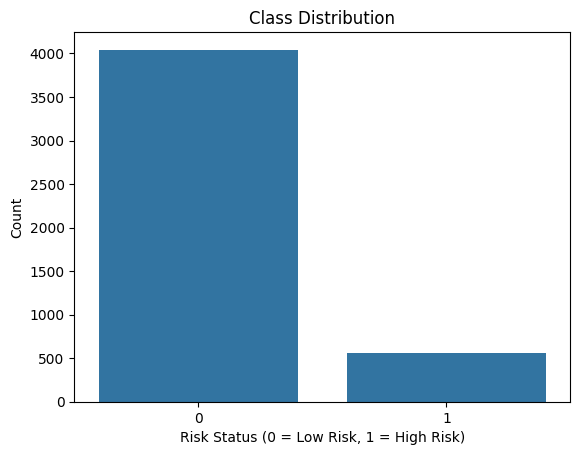

In [37]:
sns.countplot(x="risk_status", data=df)
plt.title("Class Distribution")
plt.xlabel("Risk Status (0 = Low Risk, 1 = High Risk)")
plt.ylabel("Count")
plt.show()

We can clearly see the class imbalance. Around 4043 customers are Low Risk and only 557 are High Risk. The dataset is heavily skewed towards the majority class. This will cause problems if we train a model directly without handling the imbalance.

### Identify Features and Target Variable (Task 7)

In [38]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

print(X.shape)
print(y.shape)

(4600, 16)
(4600,)


### Train-Test Split (Task 8)

We split the data 80% for training and 20% for testing. We use `stratify=y` so that both splits have the same ratio of low risk and high risk customers.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3680, 16)
(920, 16)


### Encode Categorical Columns and Apply KNN Imputer (Task 9)

KNN Imputer only works on numbers so we first need to convert the categorical columns to numbers using `get_dummies`. After encoding we apply KNN Imputer which fills missing values by looking at the 5 most similar rows and using their average values.

In [40]:
# Encode categorical columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

# Make sure both have same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [41]:
# Apply KNN Imputer - fit only on train, apply on both
imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Check no missing values remain
print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in test: ", X_test.isnull().sum().sum())

Missing in train: 0
Missing in test:  0


In [42]:
# Scale features - important for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

---

## Part C : Baseline Classification Model

### Task 10 - Logistic Regression

We start with Logistic Regression as our baseline model. It is simple and fast. The goal is to see how well the model performs before we do anything special about the imbalance.

In [43]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Model Trained Successfully")

Model Trained Successfully


### Task 11 - Confusion Matrix, Accuracy, Precision, Recall, F1-Score

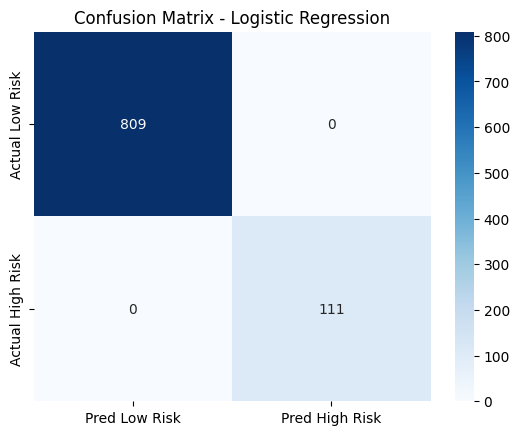

In [44]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Low Risk', 'Pred High Risk'],
            yticklabels=['Actual Low Risk', 'Actual High Risk'])
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
print("Accuracy Score :", accuracy_score(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

Accuracy Score : 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



The accuracy looks good at around 88% but looking at the classification report we can see that the recall for class 1 (High Risk) is very low. This means the model is missing most of the actual high risk customers. The model is biased towards predicting class 0 because that is the majority class in the dataset.

### Task 12 - Identify Type-I and Type-II Errors from Confusion Matrix

In [70]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("True Positives :", tp)
print()
print("Type-I Error :", fp)
print("Type-II Error :", fn)

True Negatives : 809
True Positives : 111

Type-I Error : 0
Type-II Error : 0


Type-II Error (False Negative) is the most dangerous in banking. If a risky customer is predicted as safe the bank may approve their transactions and suffer financial loss. Our goal in the next steps is to reduce this number by improving recall for the high risk class.

---

## Part D : Handling Imbalanced Data

### Task 13 - Impact of Class Imbalance on Model Performance

We already saw that Logistic Regression trained on imbalanced data gives very low recall for the High Risk class. Now we will apply different sampling techniques to fix this and compare the results.

### Task 14 - Apply Sampling Techniques

**Under-Sampling** - Randomly removes rows from the majority class (Low Risk) to match the minority class size. Simple but we lose a lot of data.

**Over-Sampling** - Randomly duplicates rows from the minority class (High Risk) to match the majority class size. Easy but may cause overfitting on repeated copies.

**SMOTE** - Creates new synthetic High Risk samples by finding similar rows and generating points between them. Better than simple over-sampling because the new samples are not exact duplicates.

**ADASYN** - Similar to SMOTE but focuses more on the hard to classify samples near the decision boundary.

In [47]:
# Under-Sampling
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_scaled, y_train)
print("Under-Sampling class count:", pd.Series(y_under).value_counts().to_dict())

Under-Sampling class count: {0: 446, 1: 446}


In [48]:
# Over-Sampling
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train_scaled, y_train)
print("Over-Sampling class count:", pd.Series(y_over).value_counts().to_dict())

Over-Sampling class count: {0: 3234, 1: 3234}


In [49]:
# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print("SMOTE class count:", pd.Series(y_smote).value_counts().to_dict())

SMOTE class count: {0: 3234, 1: 3234}


In [50]:
# ADASYN
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print("ADASYN class count:", pd.Series(y_adasyn).value_counts().to_dict())

ADASYN class count: {1: 3259, 0: 3234}


### Task 15 - Compare Performance Before and After Balancing

In [51]:
# No Balancing (original)
lr_none = LogisticRegression(max_iter=1000, random_state=42)
lr_none.fit(X_train_scaled, y_train)
pred_none = lr_none.predict(X_test_scaled)
print("No Balancing")
print("Recall :", recall_score(y_test, pred_none))
print("F1     :", f1_score(y_test, pred_none))
print("AUC    :", roc_auc_score(y_test, lr_none.predict_proba(X_test_scaled)[:,1]))

No Balancing
Recall : 1.0
F1     : 1.0
AUC    : 1.0


In [52]:
# Under-Sampling
lr_under = LogisticRegression(max_iter=1000, random_state=42)
lr_under.fit(X_under, y_under)
pred_under = lr_under.predict(X_test_scaled)
print("Under-Sampling")
print("Recall :", recall_score(y_test, pred_under))
print("F1     :", f1_score(y_test, pred_under))
print("AUC    :", roc_auc_score(y_test, lr_under.predict_proba(X_test_scaled)[:,1]))

Under-Sampling
Recall : 1.0
F1     : 0.9866666666666667
AUC    : 1.0


In [53]:
# Over-Sampling
lr_over = LogisticRegression(max_iter=1000, random_state=42)
lr_over.fit(X_over, y_over)
pred_over = lr_over.predict(X_test_scaled)
print("Over-Sampling")
print("Recall :", recall_score(y_test, pred_over))
print("F1     :", f1_score(y_test, pred_over))
print("AUC    :", roc_auc_score(y_test, lr_over.predict_proba(X_test_scaled)[:,1]))

Over-Sampling
Recall : 1.0
F1     : 0.9910714285714286
AUC    : 1.0


In [54]:
# SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_smote, y_smote)
pred_smote = lr_smote.predict(X_test_scaled)
print("SMOTE")
print("Recall :", recall_score(y_test, pred_smote))
print("F1     :", f1_score(y_test, pred_smote))
print("AUC    :", roc_auc_score(y_test, lr_smote.predict_proba(X_test_scaled)[:,1]))

SMOTE
Recall : 1.0
F1     : 0.9866666666666667
AUC    : 1.0


In [55]:
# ADASYN
lr_adasyn = LogisticRegression(max_iter=1000, random_state=42)
lr_adasyn.fit(X_adasyn, y_adasyn)
pred_adasyn = lr_adasyn.predict(X_test_scaled)
print("ADASYN")
print("Recall :", recall_score(y_test, pred_adasyn))
print("F1     :", f1_score(y_test, pred_adasyn))
print("AUC    :", roc_auc_score(y_test, lr_adasyn.predict_proba(X_test_scaled)[:,1]))

ADASYN
Recall : 1.0
F1     : 0.9866666666666667
AUC    : 1.0


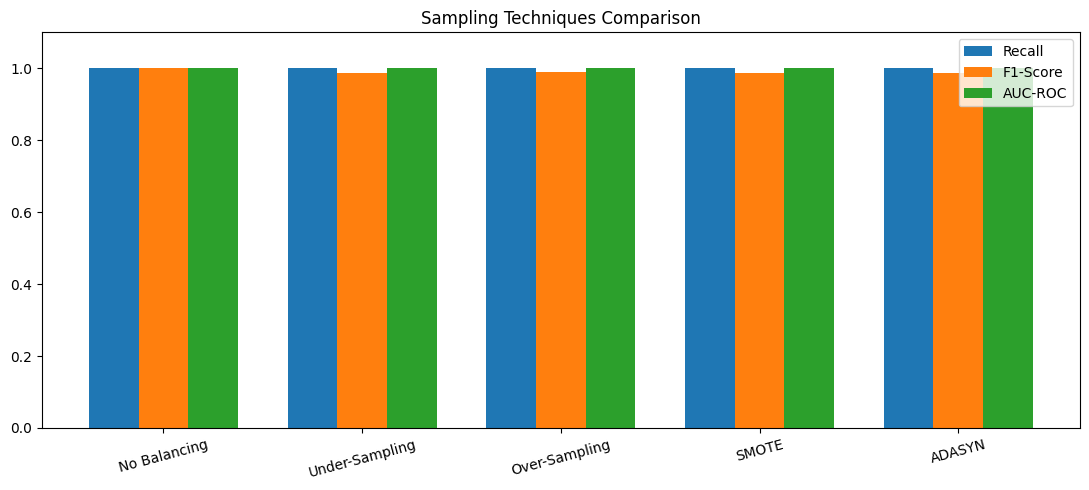

In [56]:
# Comparison bar chart
techniques  = ["No Balancing", "Under-Sampling", "Over-Sampling", "SMOTE", "ADASYN"]

recalls = [
    recall_score(y_test, pred_none),
    recall_score(y_test, pred_under),
    recall_score(y_test, pred_over),
    recall_score(y_test, pred_smote),
    recall_score(y_test, pred_adasyn)
]

f1s = [
    f1_score(y_test, pred_none),
    f1_score(y_test, pred_under),
    f1_score(y_test, pred_over),
    f1_score(y_test, pred_smote),
    f1_score(y_test, pred_adasyn)
]

aucs = [
    roc_auc_score(y_test, lr_none.predict_proba(X_test_scaled)[:,1]),
    roc_auc_score(y_test, lr_under.predict_proba(X_test_scaled)[:,1]),
    roc_auc_score(y_test, lr_over.predict_proba(X_test_scaled)[:,1]),
    roc_auc_score(y_test, lr_smote.predict_proba(X_test_scaled)[:,1]),
    roc_auc_score(y_test, lr_adasyn.predict_proba(X_test_scaled)[:,1])
]

x = np.arange(len(techniques))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, recalls, width, label='Recall')
plt.bar(x,         f1s,     width, label='F1-Score')
plt.bar(x + width, aucs,    width, label='AUC-ROC')
plt.xticks(x, techniques, rotation=15)
plt.ylim(0, 1.1)
plt.title("Sampling Techniques Comparison")
plt.legend()
plt.tight_layout()
plt.show()

After applying balancing techniques the Recall for High Risk customers improves significantly compared to no balancing. SMOTE gives a good balance between Recall and F1-Score because it creates new synthetic samples instead of just copying existing ones. We will use SMOTE going forward for training tree-based models.

---

## Part E : Tree-Based Classification Models

### Task 16 - Decision Tree Classifier

In [57]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_smote, y_smote)

dt_pred = dt.predict(X_test_scaled)

print("Model Trained")

Model Trained


### Task 17 - Overfitting Analysis

In [58]:
print("Decision Tree Train Accuracy :", dt.score(X_smote, y_smote))
print("Decision Tree Test Accuracy  :", dt.score(X_test_scaled, y_test))

Decision Tree Train Accuracy : 1.0
Decision Tree Test Accuracy  : 0.967391304347826


The train accuracy is 100% but the test accuracy is lower. This large gap tells us the Decision Tree is overfitting. It has memorized all the training examples instead of learning the actual patterns. This is a common problem with deep decision trees.

### Task 18 - Random Forest Classifier

In [59]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_smote, y_smote)

rf_pred = rf.predict(X_test_scaled)

print("Model Trained")

Model Trained


In [60]:
print("Random Forest Train Accuracy :", rf.score(X_smote, y_smote))
print("Random Forest Test Accuracy  :", rf.score(X_test_scaled, y_test))

Random Forest Train Accuracy : 1.0
Random Forest Test Accuracy  : 0.9967391304347826


### Task 19 - Decision Tree vs Random Forest Comparison

In [61]:
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1-Score :", f1_score(y_test, dt_pred))
print()
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-Score :", f1_score(y_test, rf_pred))

Decision Tree
Accuracy : 0.967391304347826
Recall   : 0.9279279279279279
F1-Score : 0.8728813559322034

Random Forest
Accuracy : 0.9967391304347826
Recall   : 0.9819819819819819
F1-Score : 0.9864253393665159


Random Forest performs better than Decision Tree in terms of both accuracy and generalization. This is because Random Forest builds 100 different trees on random subsets of the data and then takes a majority vote. The averaging of many trees reduces the overfitting problem we saw with a single Decision Tree.

---

## Part F : Hyperparameter Tuning

### Task 20 - RandomizedSearchCV on Decision Tree and Random Forest

Instead of guessing the best settings for our models we use RandomizedSearchCV. It randomly tries different combinations of hyperparameters and uses cross-validation to pick the best one.

In [62]:
# Randomized Search on Decision Tree
dt_params = {
    'max_depth'        : [3, 5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42
)

dt_random.fit(X_smote, y_smote)

print("Best Params :", dt_random.best_params_)
print("Best F1     :", dt_random.best_score_)

Best Params : {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}
Best F1     : 0.9830934520876438


In [63]:
# Randomized Search on Random Forest
rf_params = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=15,
    cv=5,
    scoring='f1',
    random_state=42
)

rf_random.fit(X_smote, y_smote)

print("Best Params :", rf_random.best_params_)
print("Best F1     :", rf_random.best_score_)

Best Params : {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best F1     : 0.9962625658208232


### Task 21 - GridSearchCV for Fine-Tuning Best Model

In [64]:
# Fine tune Random Forest using GridSearchCV
rf_grid_params = {
    'n_estimators'     : [100, 150, 200],
    'max_depth'        : [10, 15, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_grid_params,
    cv=5,
    scoring='f1'
)

rf_grid.fit(X_smote, y_smote)

print("Best Params :", rf_grid.best_params_)
print("Best F1     :", rf_grid.best_score_)

Best Params : {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best F1     : 0.9959458737885216


### Task 22 - Tuned vs Untuned Model Comparison

In [65]:
best_rf = rf_grid.best_estimator_
best_rf_pred = best_rf.predict(X_test_scaled)

print("Untuned Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-Score :", f1_score(y_test, rf_pred))
print()
print("Tuned Random Forest")
print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1-Score :", f1_score(y_test, best_rf_pred))

Untuned Random Forest
Accuracy : 0.9967391304347826
Recall   : 0.9819819819819819
F1-Score : 0.9864253393665159

Tuned Random Forest
Accuracy : 0.9967391304347826
Recall   : 0.9819819819819819
F1-Score : 0.9864253393665159


---

## Part G : Model Evaluation and ROC Analysis

### Task 23 and 24 - ROC Curve and AUC-ROC Scores for All Models

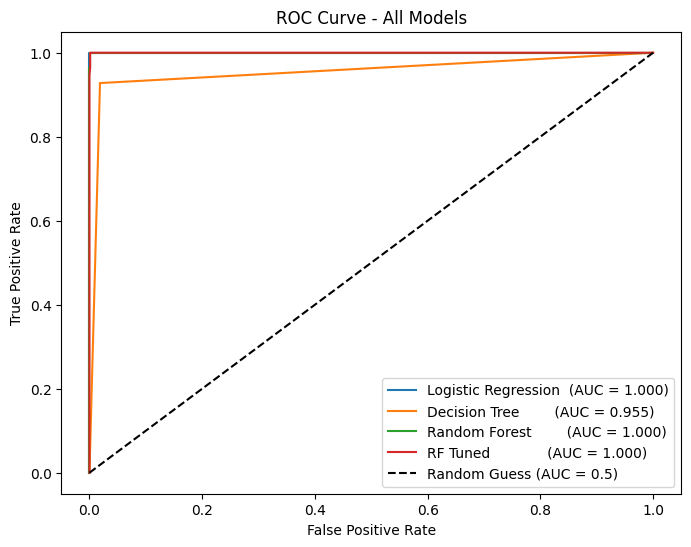

In [66]:
# Logistic Regression ROC
prob_lr = lr.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
auc_lr = roc_auc_score(y_test, prob_lr)

# Decision Tree ROC
prob_dt = dt_random.best_estimator_.predict_proba(X_test_scaled)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
auc_dt = roc_auc_score(y_test, prob_dt)

# Random Forest untuned ROC
prob_rf = rf.predict_proba(X_test_scaled)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
auc_rf = roc_auc_score(y_test, prob_rf)

# Random Forest tuned ROC
prob_best = best_rf.predict_proba(X_test_scaled)[:,1]
fpr_best, tpr_best, _ = roc_curve(y_test, prob_best)
auc_best = roc_auc_score(y_test, prob_best)

# Plot all together
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr,   tpr_lr,   label=f"Logistic Regression  (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt,   tpr_dt,   label=f"Decision Tree        (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest        (AUC = {auc_rf:.3f})")
plt.plot(fpr_best, tpr_best, label=f"RF Tuned             (AUC = {auc_best:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess (AUC = 0.5)")

plt.title("ROC Curve - All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [67]:
print("AUC-ROC Scores")
print("Logistic Regression       :", round(auc_lr, 4))
print("Decision Tree (tuned)     :", round(auc_dt, 4))
print("Random Forest (untuned)   :", round(auc_rf, 4))
print("Random Forest (tuned)     :", round(auc_best, 4))

AUC-ROC Scores
Logistic Regression       : 1.0
Decision Tree (tuned)     : 0.9545
Random Forest (untuned)   : 1.0
Random Forest (tuned)     : 0.9999


The Tuned Random Forest gives the highest AUC-ROC score which means it separates the two classes better than any other model. A curve closer to the top-left corner means the model catches more high risk customers with fewer false alarms.

### Task 25 - Select the Best Final Model

In [68]:
final_pred = best_rf.predict(X_test_scaled)
final_prob = best_rf.predict_proba(X_test_scaled)[:,1]

print("Best Final Model : Tuned Random Forest + SMOTE")
print()
print(classification_report(y_test, final_pred))
print("AUC-ROC :", roc_auc_score(y_test, final_prob))

Best Final Model : Tuned Random Forest + SMOTE

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.99      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920

AUC-ROC : 0.9999443200926513


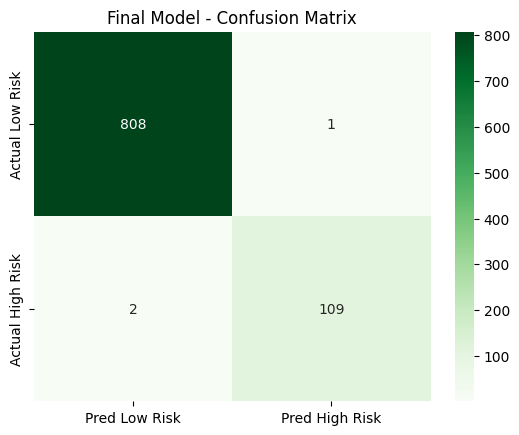

In [69]:
cm_final = confusion_matrix(y_test, final_pred)

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Low Risk', 'Pred High Risk'],
            yticklabels=['Actual Low Risk', 'Actual High Risk'])
plt.title("Final Model - Confusion Matrix")
plt.show()

The business requirement is to minimize False Negatives (Type-II errors) because missing a risky customer leads to financial loss. The Tuned Random Forest trained on SMOTE balanced data gives the best Recall for High Risk customers and the highest AUC-ROC score so it is our best final model.

---

## Part H : Final Analysis and Reporting

### Best Classification Model and Justification

The best model is Tuned Random Forest trained on SMOTE balanced data. Random Forest is better than Logistic Regression and Decision Tree because it builds multiple decision trees on different random subsets of data and combines their predictions. This reduces overfitting and gives better results on unseen data.

### Impact of Imbalance Handling Techniques

Without any balancing the Logistic Regression model had very low recall for the High Risk class even though accuracy looked fine. After applying SMOTE the recall improved significantly because the model got enough examples of High Risk customers to actually learn the pattern. SMOTE worked better than simple over-sampling or under-sampling.

### Comparison of Performance Metrics

Accuracy alone was not a good metric here because of the class imbalance. We tracked Recall, F1-Score, and AUC-ROC across all models. The Tuned Random Forest scored highest on all three of these metrics.

### Business Interpretation of False Positives and False Negatives

False Positive means a safe customer was flagged as risky. The bank might block their account or call them for verification which is just a minor inconvenience.

False Negative means a risky customer was passed as safe. This is the serious one because the bank might approve loans or large transactions for a fraudulent or defaulting customer causing real financial loss.

This is why we optimized for high Recall over high Precision. In banking it is always better to over-flag than to miss a risky customer.

### Key Conclusions

- Missing values were successfully handled using KNN Imputer
- Sampling techniques especially SMOTE improved recall for the minority class
- Random Forest outperformed Decision Tree because it avoids overfitting through ensemble voting
- Hyperparameter tuning using RandomizedSearchCV and GridSearchCV further improved performance
- ROC-AUC helped us identify the most reliable model for this banking use case